# chuq_split — setup: energy-split CHUQ calibration (Ca-40 p,el)

Two calibrations of the `jitr.optical_potentials.chuq` (CH89/CHUQ) model with **different absorption
forms**, trained on two disjoint energy bands and compared in a held-out middle band:

- **low** model: **surface-only** absorption (imag volume off, `Wv0=0`), trained on `[0, E0]`,
- **high** model: **volume-only** absorption (imag surface off, `Ws0=0`), trained on `(E1, 200]`,
- **test** region: the middle tercile `(E0, E1]`, held out of both fits.

Spin-orbit is **frozen** (Ay dropped); for this single isotope with N=Z the asymmetry terms
`Vt, Wst`, the radial intercepts `r0_0, rw_0, rc_0`, and the Coulomb radius `rc` are frozen. Each
model then has **9 free params + 1 model-error nuisance = 10 sampled dims**. Prior is a truncated
normal from the CHUQ **Democratic** posteriors (fixed a priori). Sampler: dynesty,
`likelihood_scaling = 1.0` (no rescaling), standard `UnknownModelError` fractional model error.

This notebook loads the data, shows the split + priors, seeds the MLE, and builds both configs.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# chuq_io knows where everything lives (project root derived from its own location), so no
# path in this notebook depends on where the repository is checked out.
import chuq_io
import chuq_model
import build_configs

chuq_io.use_paper_style()

datasets = chuq_io.load_datasets()
e_split_low, e_split_high, n_total_points = chuq_io.tercile_bounds(datasets)
bands = chuq_io.split_bands(datasets, e_split_low, e_split_high)

print(
    f"{n_total_points} points / {len(datasets)} datasets   "
    f"E0={e_split_low:.1f}  E1={e_split_high:.1f} MeV"
)
for band_name in chuq_io.BAND_NAMES:
    band_points = chuq_io.total_points(bands[band_name])
    print(
        f"  {band_name:4s}: {len(bands[band_name]):2d} sets, {band_points:4d} pts "
        f"({band_points / n_total_points:.0%})"
    )

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


1735 points / 51 datasets   E0=19.6  E1=40.0 MeV
  low : 25 sets,  582 pts (34%)
  test: 13 sets,  680 pts (39%)
  high: 13 sets,  473 pts (27%)


## Energy split — three point-count terciles

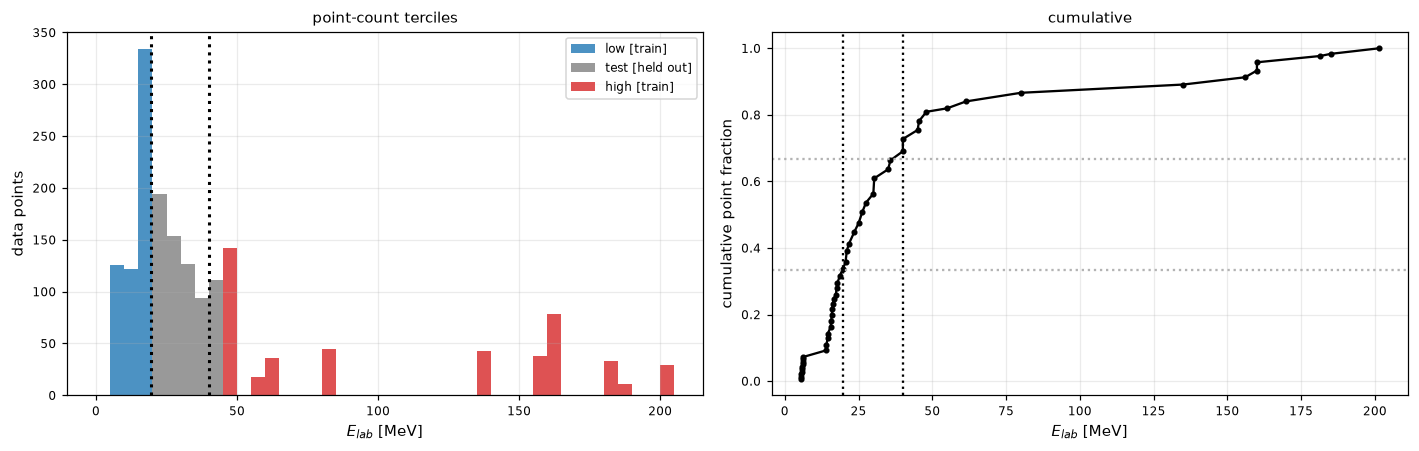

In [2]:
# Left panel: how many DATA POINTS fall in each band -- the terciles balance points, not
# datasets and not energy width, so the low band is much narrower in energy than the high one.
# Right panel: the cumulative point fraction. This is the panel that demonstrates the split is
# what it claims to be -- the two boundaries land where the curve crosses 1/3 and 2/3.
BAND_STYLE = {
    "low": ("tab:blue", "low [train]"),
    "test": ("0.5", "test [held out]"),
    "high": ("tab:red", "high [train]"),
}
ENERGY_HIST_BINS = np.linspace(0, 205, 42)  # ~5 MeV wide, spanning the 5.4-201 MeV data

e_lab_per_dataset = np.array([chuq_io.elab(d) for d in datasets])
points_per_dataset = np.array([chuq_io.n_points(d) for d in datasets])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for band_name in chuq_io.BAND_NAMES:
    color, legend_label = BAND_STYLE[band_name]
    axes[0].hist(
        [chuq_io.elab(d) for d in bands[band_name]],
        bins=ENERGY_HIST_BINS,
        weights=[chuq_io.n_points(d) for d in bands[band_name]],
        color=color,
        alpha=0.8,
        label=legend_label,
    )
for boundary in (e_split_low, e_split_high):
    axes[0].axvline(boundary, color="k", ls=":", lw=2)
axes[0].set_xlabel(r"$E_{lab}$ [MeV]")
axes[0].set_ylabel("data points")
axes[0].legend()
axes[0].set_title("point-count terciles")

sort_by_energy = np.argsort(e_lab_per_dataset)
axes[1].plot(
    e_lab_per_dataset[sort_by_energy],
    np.cumsum(points_per_dataset[sort_by_energy]) / n_total_points,
    "k.-",
)
for boundary, target_fraction in ((e_split_low, 1 / 3), (e_split_high, 2 / 3)):
    axes[1].axvline(boundary, color="k", ls=":")
    axes[1].axhline(target_fraction, color="0.7", ls=":")
axes[1].set_xlabel(r"$E_{lab}$ [MeV]")
axes[1].set_ylabel("cumulative point fraction")
axes[1].set_title("cumulative")

fig.tight_layout()
chuq_io.save_figure(fig, "split_terciles")
plt.show()

## Priors — CHUQ Democratic posteriors (fixed a priori), per variant

In [3]:
priors_by_variant = {v: chuq_model.democratic_prior(v) for v in chuq_io.VARIANT_NAMES}

for variant in chuq_io.VARIANT_NAMES:
    prior_mean, prior_std, trunc_lo, trunc_hi = priors_by_variant[variant]
    print(
        f"=== {variant}  ({chuq_io.VARIANT_FORM[variant]} absorption, "
        f"{chuq_model.n_omp(variant)} free) ==="
    )
    display(
        pd.DataFrame(
            {
                "param": chuq_model.free_names(variant),
                "prior_mean": prior_mean.round(3),
                "prior_std": prior_std.round(3),
                "trunc_lo": trunc_lo,
                "trunc_hi": trunc_hi,
            }
        )
    )

print("Shared frozen (Democratic means):")
print(pd.Series(chuq_model.democratic_frozen()).round(3).to_string())
print(
    "\nper-variant zeroed channel: low Wv0=0 (+Wve0,Wvew inert); "
    "high Ws0=0 (+Wse0,Wsew inert)"
)

=== low  (surface-only absorption, 9 free) ===


,param,prior_mean,prior_std,trunc_lo,trunc_hi
0,V0,56.089,1.716,30.0,90.0
1,Ve,-0.358,0.030,-1.0,0.5
2,r0,1.197,0.032,0.9,1.5
3,a0,0.734,0.029,0.3,1.0
4,rw,1.327,0.080,0.9,1.7
5,aw,0.695,0.052,0.3,1.0
6,Ws0,10.916,4.035,0.0,40.0
7,Wse0,19.362,22.791,-80.0,140.0
8,Wsew,60.000,10.000,1.0,150.0


=== high  (volume-only absorption, 9 free) ===


,param,prior_mean,prior_std,trunc_lo,trunc_hi
0,V0,56.089,1.716,30.0,90.0
1,Ve,-0.358,0.030,-1.0,0.5
2,r0,1.197,0.032,0.9,1.5
3,a0,0.734,0.029,0.3,1.0
4,Wv0,10.556,3.904,0.0,40.0
5,Wve0,34.386,22.354,-80.0,140.0
6,Wvew,24.908,9.982,1.0,90.0
7,rw,1.327,0.080,0.9,1.7
8,aw,0.695,0.052,0.3,1.0


Shared frozen (Democratic means):
Vt       13.934
Wst      28.858
Vso       5.531
rso       1.301
rso_0    -1.129
aso       0.608
r0_0     -0.195
rw_0     -0.398
rc_0      0.129
rc        1.247

per-variant zeroed channel: low Wv0=0 (+Wve0,Wvew inert); high Ws0=0 (+Wse0,Wsew inert)


## Prior-predictive sanity

Overlay the **prior-mean** low (surface-only) & high (volume-only) models and the published CH89
default on a few datasets from each band. Confirms the chuq wiring produces sensible dσ/dΩ/Ruth.

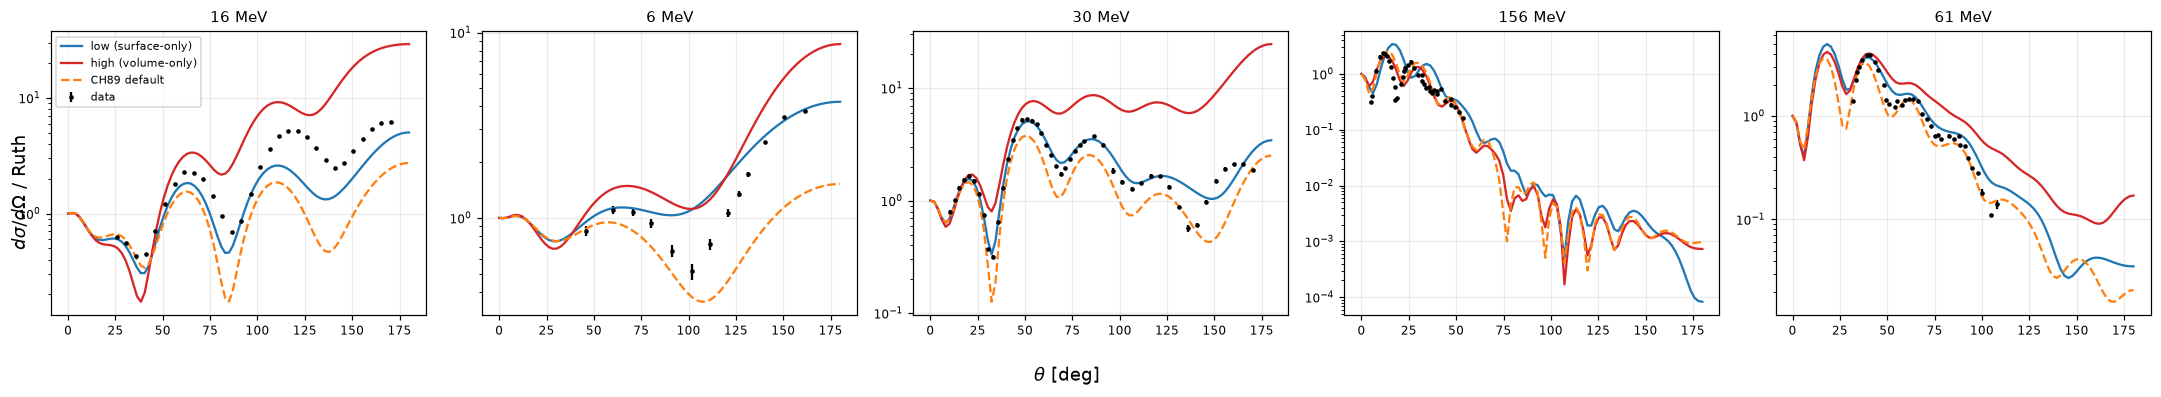

In [4]:
models_by_variant = {v: chuq_model.build_model(v) for v in chuq_io.VARIANT_NAMES}
prior_mean_by_variant = {v: priors_by_variant[v][0] for v in chuq_io.VARIANT_NAMES}

# One dataset from each end of the low band, the middle of the held-out band, and the middle
# and top of the high band -- enough spread to catch a wiring error at any energy.
example_datasets = [
    bands["low"][0],
    bands["low"][len(bands["low"]) // 2],
    bands["test"][len(bands["test"]) // 2],
    bands["high"][len(bands["high"]) // 2],
    bands["high"][-1],
]

fig, axes = plt.subplots(
    1, len(example_datasets), figsize=(4 * len(example_datasets), 3.6)
)
for ax, dataset in zip(np.atleast_1d(axes), example_datasets):
    chuq_io.plot_dataset(ax, dataset)
    theta_grid_deg = chuq_io.visualization_angles_deg(dataset)
    for variant in chuq_io.VARIANT_NAMES:
        ax.plot(
            theta_grid_deg,
            models_by_variant[variant].visualizable_model_prediction(
                dataset, *prior_mean_by_variant[variant]
            ),
            color=chuq_io.VARIANT_COLOR[variant],
            label=f"{variant} ({chuq_io.VARIANT_FORM[variant]})",
        )
    ax.plot(
        theta_grid_deg,
        chuq_model.builtin_prediction(dataset, visualize=True),
        color="tab:orange",
        ls="--",
        label="CH89 default",
    )
    ax.set_title(f"{chuq_io.elab(dataset):.0f} MeV")

axes[0].legend(fontsize=7)
fig.supxlabel(r"$\theta$ [deg]")
fig.supylabel(r"$d\sigma/d\Omega\ /\ $Ruth")
fig.tight_layout()
chuq_io.save_figure(fig, "prior_predictive")
plt.show()

## Build both configs

`build_configs.main()` is the canonical builder, and the same code path the command line uses
(`python build_configs.py`). It recomputes the split, runs a multi-start **MLE seed** for each
variant on that variant's own band (likelihood only, no prior -- dynesty does not need a good
starting point, but a sane one shortens the initial exploration and flags parameters whose
best fit sits against a support bound), builds
`calibrations/chuq_{low,high}/config.pkl` with `likelihood_scaling=1.0`, renders a
`dynesty.slurm` for each from `dynesty.slurm.template` + `site.env`, and writes
`calibrations/fit_info.json`.

**It does not submit, and it does not overwrite.** If a `config.pkl` already exists the variant
is skipped before the expensive MLE, so re-running this notebook cannot destroy a finished
calibration. Pass `force=True` (or `--force`) to deliberately rebuild.

In [5]:
build_configs.main()

N=1735 pts over 51 datasets, terciles E0=19.6, E1=40.0 MeV
  low  [<= 19.6]       : 25 sets,  582 pts (34%)
  test (19.6, 40.0]    : 13 sets,  680 pts (39%)  [held out]
  high (> 40.0]        : 13 sets,  473 pts (27%)
  [low] calibrations/chuq_low/config.pkl already exists -- not overwritten (pass --force to rebuild)
  [high] calibrations/chuq_high/config.pkl already exists -- not overwritten (pass --force to rebuild)

nothing rebuilt; calibrations/fit_info.json left untouched

(--submit not passed) submit them with:
  sbatch calibrations/chuq_low/dynesty.slurm
  sbatch calibrations/chuq_high/dynesty.slurm


['/mnt/ufs18/rs/reactiontheoryinitiative/model_mixing/chuq_split/calibrations/chuq_low/dynesty.slurm',
 '/mnt/ufs18/rs/reactiontheoryinitiative/model_mixing/chuq_split/calibrations/chuq_high/dynesty.slurm']

## Serial round-trip smoke check

In [6]:
# The same check `smoke_test.py` runs: evaluate each built config at the prior median and
# confirm the log-posterior is finite. u = 0.5 is the prior median in every coordinate because
# prior_transform is a per-coordinate inverse CDF.
import dill

for variant in chuq_io.VARIANT_NAMES:
    with open(chuq_io.run_dir(variant) / "config.pkl", "rb") as stream:
        config = dill.load(stream)
    n_dims = len(config.parameter_names)
    theta_prior_median = config.prior_transform(np.full(n_dims, 0.5))
    log_posterior = config.log_posterior(theta_prior_median)
    print(
        f"[{variant}] dim={n_dims}  log_posterior(prior median)={log_posterior:.2f}  "
        f"finite={np.isfinite(log_posterior)}"
    )

[low] dim=10  log_posterior(prior median)=-9256.15  finite=True


[high] dim=10  log_posterior(prior median)=-37660.90  finite=True


## Next steps

```bash
bash setup_mpi.sh          # once per machine: rebuild mpi4py against the local MPI
./submit.sh sample low     # nested sampling, ~36 h on 65 ranks
./submit.sh sample high
```

`submit.sh` reads the account, partition and MPI launcher from `site.env` -- that file is the
only thing to edit when moving to a different cluster.

Then **chuq_analysis.ipynb** compares the two models in the held-out test region, and
**chuq_coverage.ipynb** checks whether their posterior-predictive intervals are calibrated.